# Configuration

In [51]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [52]:
# Set up Random SEED
SEED = 100
np.random.seed(SEED)
# Control data size
nrows = 5124
DAYS_TO_PREDICT = 90
FEATURES = ["X1", "X2", "X3"]
TARGET = "y"
COLUMNS = FEATURES + [TARGET]

# Data

In [53]:
# create a date range
dates = pd.date_range(start="1999-11-17", periods=nrows, freq="D")

# create a random dataframe
data = pd.DataFrame(np.random.randn(nrows, len(COLUMNS)), index=dates, columns=COLUMNS)

# create TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5, test_size=DAYS_TO_PREDICT, gap=1)

In [55]:
# Examples to show Dataset
data.tail(5)

,X1,X2,X3,y
2013-11-22,0.236632,1.915702,0.544633,-0.110481
2013-11-23,0.478005,-0.203294,-0.165001,0.631766
2013-11-24,-1.369339,2.188914,-0.467300,-0.243952
2013-11-25,-0.533710,0.660889,-0.392533,0.958331
2013-11-26,0.013168,-0.270417,0.229628,-1.227275


# Model

In [56]:
fold = 0
preds, tests = [], []
scores = []
for train_idx, test_idx in tss.split(data):
    train = data.iloc[train_idx]
    test = data.iloc[test_idx]

    X_train = train[FEATURES]
    y_train = train[TARGET]
    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(n_estimators=100, early_stopping_rounds=50,
                           max_depth=3, random_state=SEED, objective='reg:squarederror')
    reg.fit(X_train, y_train, eval_set=[(X_train,y_train), (X_test, y_test)], verbose=100)
    
    y_pred = reg.predict(X_test)
    y_pred = pd.Series(y_pred, index=y_test.index)
    
    tests.append(y_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

[0]	validation_0-rmse:1.00680	validation_1-rmse:0.99970
[61]	validation_0-rmse:0.94641	validation_1-rmse:1.03747
[0]	validation_0-rmse:1.00680	validation_1-rmse:1.00396
[49]	validation_0-rmse:0.95606	validation_1-rmse:1.02501
[0]	validation_0-rmse:1.00635	validation_1-rmse:1.05181
[50]	validation_0-rmse:0.95619	validation_1-rmse:1.07901
[0]	validation_0-rmse:1.00759	validation_1-rmse:1.00697
[88]	validation_0-rmse:0.92878	validation_1-rmse:0.98261
[0]	validation_0-rmse:1.00757	validation_1-rmse:0.88590
[80]	validation_0-rmse:0.93577	validation_1-rmse:0.89281


# Visualize Prediction

In [57]:
print(f"Average Errors: {np.mean(scores):.4f}")

Average Errors: 0.9811


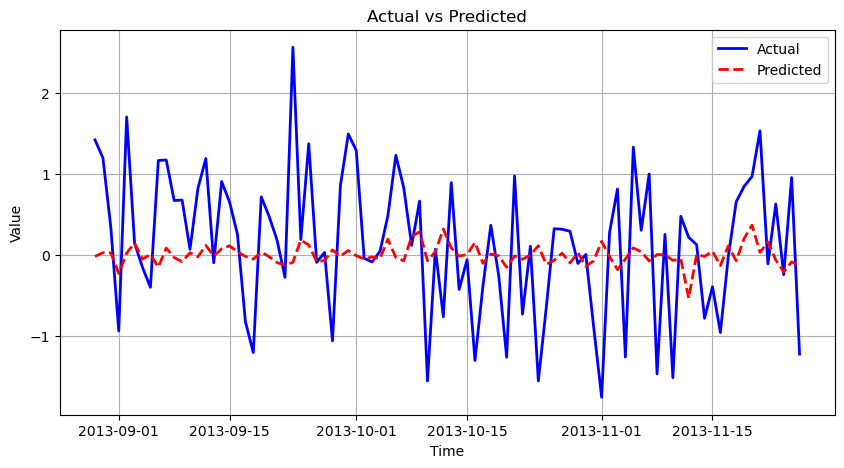

In [58]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(tests[-1], label='Actual', color='blue', linewidth=2)
plt.plot(preds[-1], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()